In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/sudan.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [3]:
df["Country"] = "Sudan"

In [4]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

In [5]:
df["Month"] = df["date"].dt.month

In [6]:
df = df.replace(-999, np.nan)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


In [10]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
date           0.0
Month          0.0
dtype: float64

In [11]:
missing_percent[missing_percent > 5]

Series([], dtype: float64)

In [12]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)
outliers_count = outliers.sum()

outliers_count

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64

In [13]:
for col in cols:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)

In [14]:
df= df.ffill()

In [15]:
df = df.dropna()

In [17]:
df.to_csv("../data/sudan_clean.csv", index=False)

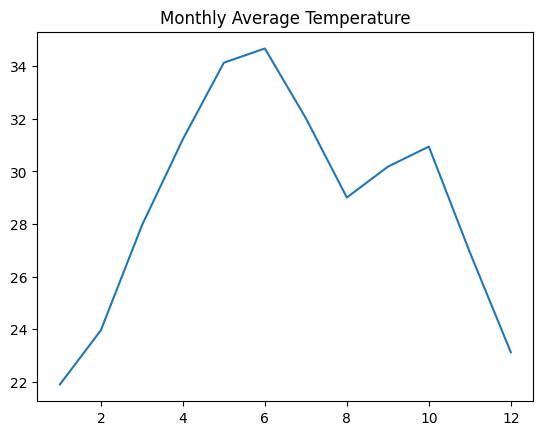

In [18]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature")
plt.show()

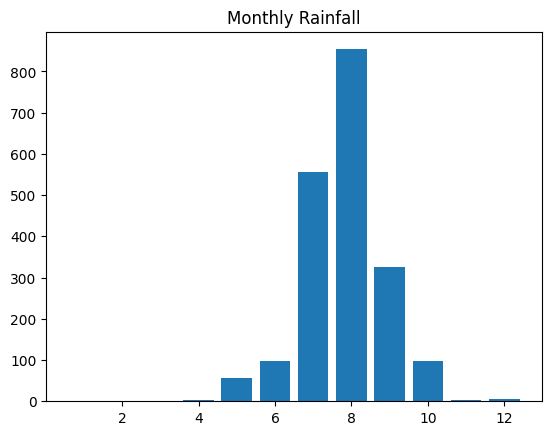

In [19]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.show()

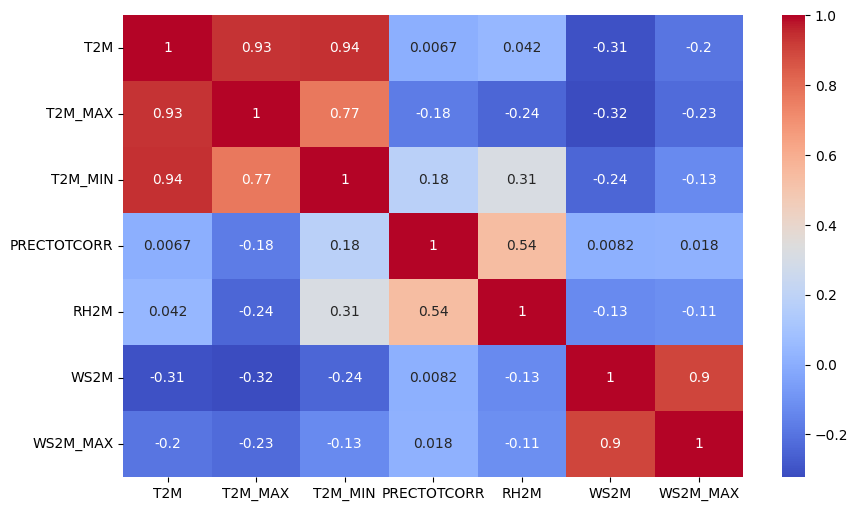

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

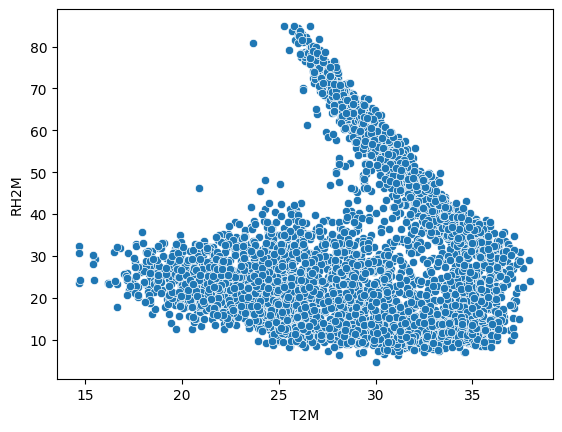

In [21]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

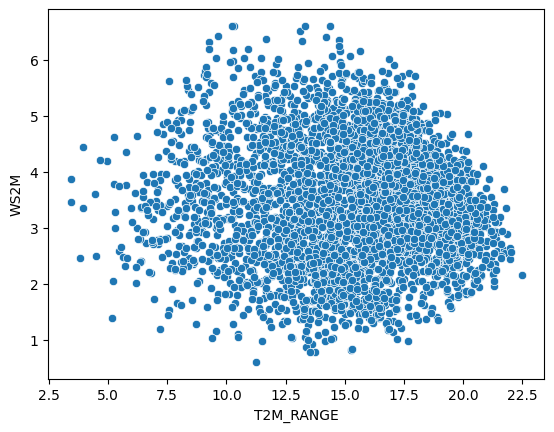

In [22]:
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.show()

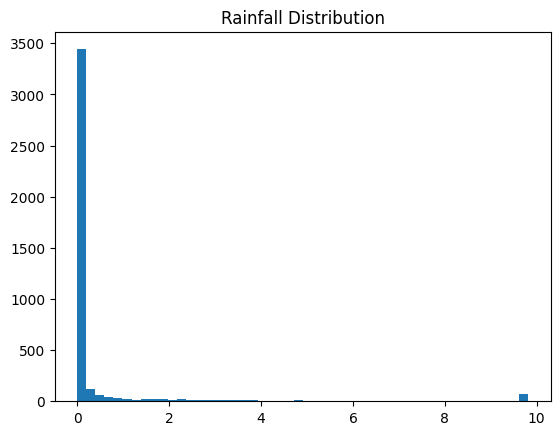

In [23]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

# Climate Analysis Report 

## Temperature Trends
The **Monthly Average Temperature** plot reveals a distinctive "M-shaped" thermal pattern over the year:
* **Initial Peak:** Temperatures rise early in the year, hitting a high in **April (Month 4)** at approximately **28.1°C**.
* **Summer Cooling:** A noticeable dip occurs mid-year, with the annual low reaching **25.2°C** in **August (Month 8)**.
* **Secondary Peak:** Temperatures recover in the autumn, peaking again in **October (Month 10)** at **27.4°C** before the year-end cooling.

## Rainfall Patterns
The **Monthly Rainfall** bar chart shows a clear bimodal monsoon cycle, typical of certain tropical latitudes:
* **Primary Wet Season:** Precipitation surges to its highest level in **May (Month 5)**, nearly reaching **2,500 units**.
* **Secondary Wet Season:** After a drier July/August, rainfall spikes again in **September (Month 9)**.
* **Dry Season:** The beginning (January/February) and end (December) of the year are significantly drier, with February being the absolute minimum.
* **Distribution:** The **Rainfall Distribution** histogram is highly skewed. While most days record minimal rain, there is a distinct frequency of extreme events at the **25-unit** mark, indicating heavy convective storms.

## Strongest Correlations
The **Correlation Heatmap** identifies the dominant relationships between variables:
* **Wind Consistency:** The **strongest correlations** in the dataset exist between **WS2M (Wind Speed)** and **WS2M_MAX** (**0.94**), showing that peak gusts are highly predictable based on average speeds.
* **Temperature Drivers:** Average daily temperature (**T2M**) is almost perfectly correlated with the daily minimum temperature (**0.93**), suggesting that nighttime heat retention is a major driver of the local climate.
* **Rainfall & Humidity:** A positive correlation (**0.51**) between **PRECTOTCORR** and **RH2M** confirms that rainy periods are consistently the most humid.

## Anomalies and Observations
* **Temperature and Humidity Divergence:** The scatter plot for **RH2M vs. T2M** shows a negative relationship. This confirms that **temperature and humidity show a negative correlation**, meaning the hottest months (like April) occur just before the peak of the rainy season when relative humidity is not yet at its maximum.
* **Wind Speed Trends:** The scatter plot for **WS2M vs. T2M_RANGE** suggests that higher wind speeds often coincide with a smaller daily temperature range, likely because wind prevents the air from stagnating and heating up excessively during the day.
* **Outliers:** The rainfall distribution shows a significant "gap" between common light rain and rare heavy downpours, suggesting that when it rains in this region, it is often either a light drizzle or an extreme event.

---
**Summary Statement:** > *“Temperature and humidity show a negative correlation, meaning hotter months tend to be drier, while the rainfall patterns are defined by two distinct monsoon peaks in May and September.”*